In this task, we are using the Mall Customers dataset which contains basic information about customers such as age, gender, income, and spending score. The goal is to understand customer behavior and group similar customers together.

#1. Import Libraries

In [3]:
# basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machnie learning libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

##Uploading Dataset

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


#2. Loading Dataset

In [5]:
# loading dataset
df = pd.read_csv("Mall_Customers.csv")

# showing  first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#3.Initial Data Inspection
First, we explore the dataset to understand its structure, check for dataset shape and general information

In [21]:
# Check dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# checking info
df.info()



Number of rows: 200
Number of columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Gender                  200 non-null    object 
 2   Age                     200 non-null    int64  
 3   Annual Income (k$)      200 non-null    int64  
 4   Spending Score (1-100)  200 non-null    int64  
 5   Cluster                 200 non-null    int32  
 6   Cluster Label           200 non-null    object 
 7   PCA1                    200 non-null    float64
 8   PCA2                    200 non-null    float64
dtypes: float64(2), int32(1), int64(4), object(2)
memory usage: 13.4+ KB


In [26]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster,PCA1,PCA2
count,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,2.000000e+02
mean,100.500000,38.850000,60.560000,50.200000,1.400000,1.065814e-16,3.552714e-17
std,57.879185,13.969007,26.264721,25.823522,1.449311,1.007461e+00,9.975332e-01
min,1.000000,18.000000,15.000000,1.000000,0.000000,-2.417385e+00,-2.461307e+00
25%,50.750000,28.750000,41.500000,34.750000,0.000000,-4.323694e-01,-4.499386e-01
50%,100.500000,36.000000,61.500000,50.000000,1.000000,-1.251055e-01,-1.185058e-01
75%,150.250000,49.000000,78.000000,73.000000,3.000000,3.607120e-01,3.008815e-01
max,200.000000,70.000000,137.000000,99.000000,4.000000,2.963498e+00,2.947027e+00


# 4. Data Preprocessing

Before applying clustering, the dataset is cleaned and prepared to ensure that the features used for customer segmentation are suitable for K-Means clustering.

The preprocessing steps include:

- Checking for missing values
- Checking for duplicate records
- Identifying and managing irrelevant columns
- Checking data types
- Selecting relevant customer features
- Scaling numerical features
- Evaluating whether categorical variables are required for clustering

### Data Types

The data types of all variables are checked to determine whether any conversion or encoding is required before clustering.

In [18]:
# Check data types
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64
Cluster,int32
Cluster Label,object
PCA1,float64
PCA2,float64


### Missing Value Handling

Missing values were checked for all columns. The dataset does not contain missing values, so no imputation or row removal was required.

In [19]:
# checking for missing values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0
Cluster,0
Cluster Label,0
PCA1,0
PCA2,0


### Duplicate Records

Duplicate records were checked to ensure that the same customer record was not unintentionally included more than once.

In [20]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

### Managing Irrelevant Features

`CustomerID` is an identifier assigned to each customer and does not represent customer behavior or characteristics. Therefore, it is excluded from the clustering features.

The remaining customer attributes are considered for segmentation based on their relevance to customer characteristics and spending behavior.

### Categorical Variable Consideration

`Gender` is a categorical variable. It is retained in the dataset for exploratory analysis and later interpretation of customer segments.

For K-Means clustering, the numerical customer characteristics are used because the clustering process is based on distances between feature values. Therefore, Gender is not included in the initial clustering feature set.

For clustering, we select only the most relevant numerical features that represent customer behavior clearly.


In [22]:
# Select relevant numerical features for clustering
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X = df[features]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


### Selected Features

The selected features represent three important customer characteristics:

- **Age** – demographic characteristic
- **Annual Income** – economic characteristic
- **Spending Score** – customer spending behavior

These variables provide meaningful information for identifying groups of customers with similar characteristics.

In [23]:
# Summary statistics of selected clustering features
X.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


# 5. EDA(Exploratory Data Analysis)



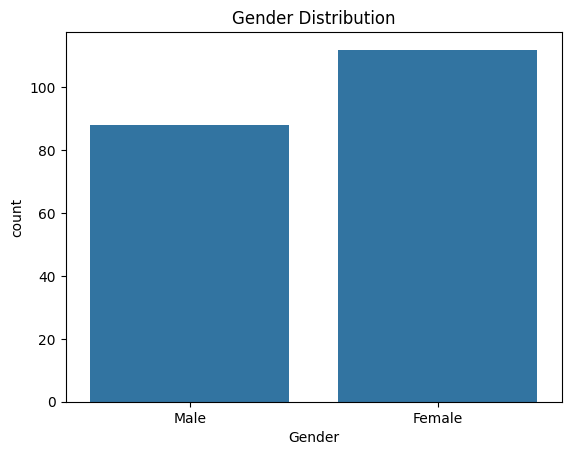

In [7]:
# gender distribution
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

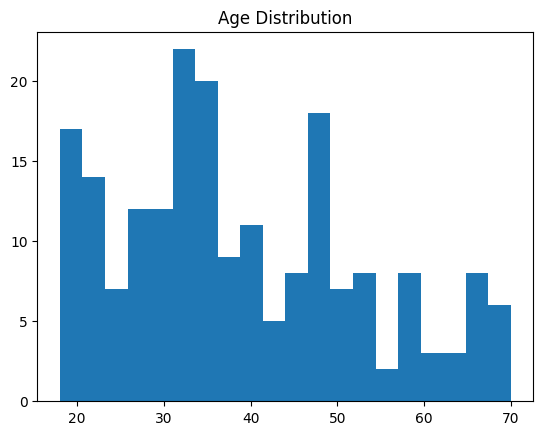

In [8]:
# age distribution
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

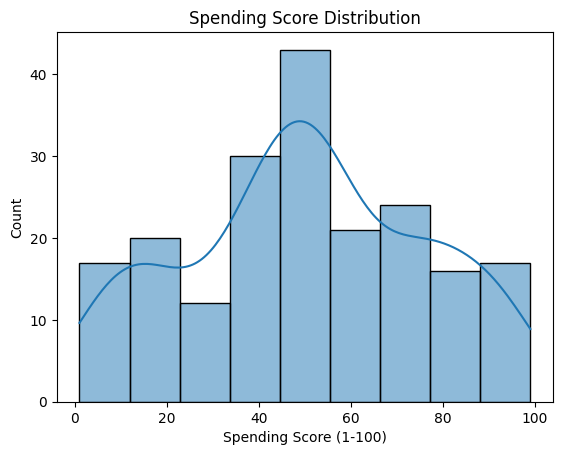

In [9]:
# spending score distribution
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title("Spending Score Distribution")
plt.show()

#5. Feature Scaling

K-Means clustering is distance-based, so features with larger numerical ranges can have a greater influence on the clustering process.

To ensure that all selected features contribute fairly, StandardScaler is used to standardize the numerical variables.

After scaling, the features have approximately:

- Mean = 0
- Standard deviation = 1

This produces a comparable scale for Age, Annual Income, and Spending Score before applying K-Means clustering.

In [24]:
from sklearn.preprocessing import StandardScaler

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame for inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [25]:
# Verify the scaled features
X_scaled_df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02,2.000000e+02
mean,-1.021405e-16,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.496335e+00,-1.738999e+00,-1.910021e+00
25%,-7.248436e-01,-7.275093e-01,-5.997931e-01
50%,-2.045351e-01,3.587926e-02,-7.764312e-03
75%,7.284319e-01,6.656748e-01,8.851316e-01
max,2.235532e+00,2.917671e+00,1.894492e+00


#7. Determine Optimal Number of Clusters

### Elbow Method

The Elbow Method is used to identify a suitable number of clusters for K-Means clustering. It calculates the Within-Cluster Sum of Squares (WCSS) for different values of K. The point where the decrease in WCSS begins to slow down indicates a possible optimal number of clusters.

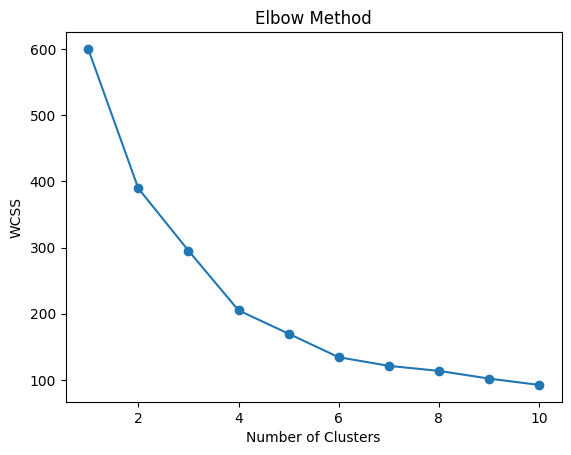

In [27]:

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Silhouette Score

The Silhouette Score is used to further evaluate the quality of clustering for different numbers of clusters. It measures how similar each customer is to its assigned cluster compared with other clusters.

A higher Silhouette Score indicates better-defined and more separated clusters.

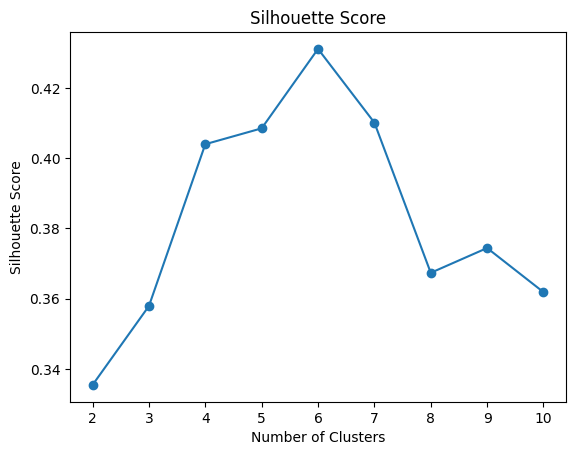

In [28]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

#8. K-Means Clustering

After determining the optimal number of clusters, we apply K-Means algorithm to group customers into different segments.

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df['Cluster Label'] = df['Cluster'].map({
    0: "Low Income Low Spender",
    1: "High Income High Spender",
    2: "Medium Spender",
    3: "Luxury Shoppers",
    4: "Careful Spenders"
})
df.head()



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster Label
0,1,Male,19,15,39,4,Careful Spenders
1,2,Male,21,15,81,2,Medium Spender
2,3,Female,20,16,6,4,Careful Spenders
3,4,Female,23,16,77,2,Medium Spender
4,5,Female,31,17,40,4,Careful Spenders


#9. Cluster Visualization

We visualize the clusters using scatter plots and PCA to better understand how customers are grouped.

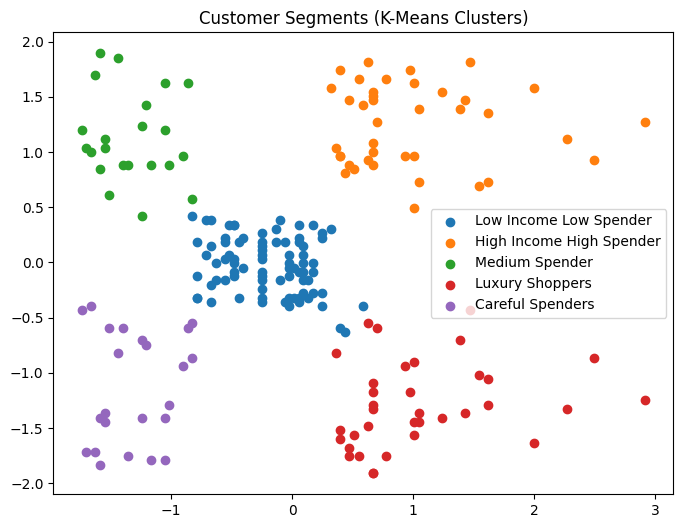

In [14]:
# Visualizing the  Clusters

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[df['Cluster']==0,0], X_scaled[df['Cluster']==0,1], label='Low Income Low Spender')
plt.scatter(X_scaled[df['Cluster']==1,0], X_scaled[df['Cluster']==1,1], label='High Income High Spender')
plt.scatter(X_scaled[df['Cluster']==2,0], X_scaled[df['Cluster']==2,1], label='Medium Spender')
plt.scatter(X_scaled[df['Cluster']==3,0], X_scaled[df['Cluster']==3,1], label='Luxury Shoppers')
plt.scatter(X_scaled[df['Cluster']==4,0], X_scaled[df['Cluster']==4,1], label='Careful Spenders')

plt.title("Customer Segments (K-Means Clusters)")
plt.legend()
plt.show()

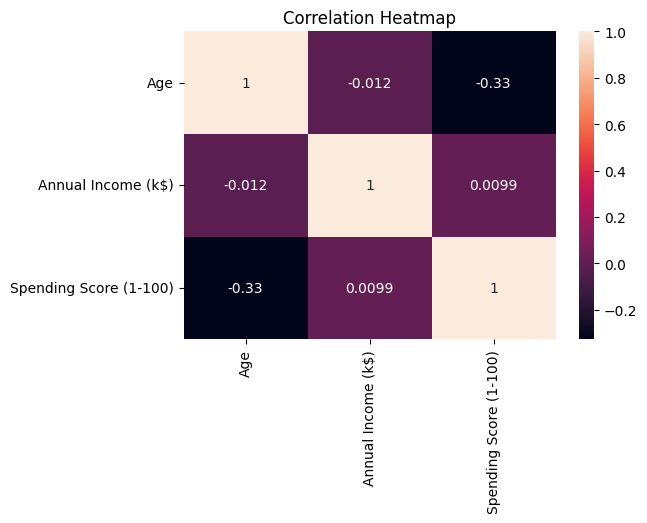

In [15]:
# Correlation Heatmap (Understanding relationships between features)
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

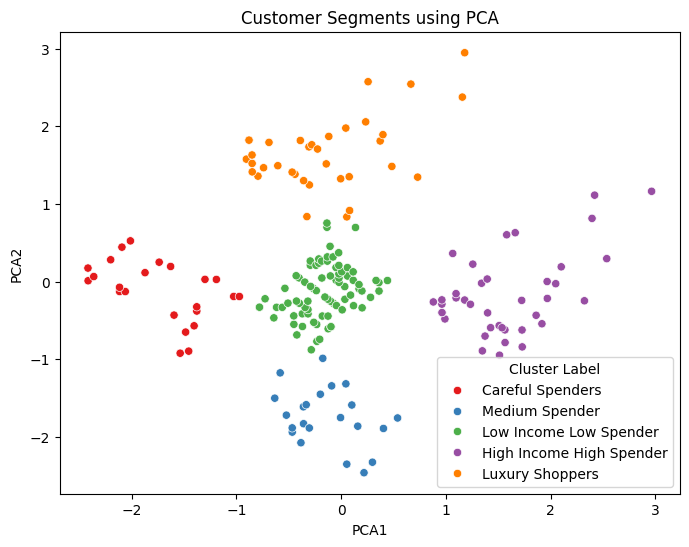

In [16]:
# PCA for 2D visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster Label',
    data=df,
    palette='Set1'
)

plt.title("Customer Segments using PCA")
plt.show()

#10. Segment Interpretation

In [17]:
# Step 12: Cluster-wise analysis

df.groupby('Cluster Label')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster Label,,,
Careful Spenders,45.217391,26.304348,20.913043
High Income High Spender,32.692308,86.538462,82.128205
Low Income Low Spender,42.716049,55.296296,49.518519
Luxury Shoppers,41.114286,88.200000,17.114286
Medium Spender,25.272727,25.727273,79.363636


#11. Business Insights & Recommendations

**CONCLUSION**

Customers are divided into clear groups based on their income, age, and spending behavior using K-Means clustering. Some groups like High Income High Spenders are very valuable for business, while Luxury Shoppers have high income but low spending and need better marketing focus. Other groups like Careful Spenders and Low Income Low Spenders show budget-sensitive behavior. Overall, clustering helps to understand customers better and supports targeted marketing strategies.